<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

## Solucion: Traductor seq2seq Ingles a Espanol

En esta solucion replicamos el traductor neuronal visto en clase (arquitectura
*encoder decoder* basada en LSTM con embeddings GloVe en el encoder) y lo
extendemos en tres ejes:

* **Conjunto de datos mas amplio:** se pasa de 10000 a 30000 pares de oraciones.
* **Secuencias de mayor longitud:** las longitudes maximas pasan de 20 y 22 en
  clase a 30 y 32, para cubrir las oraciones mas largas del corpus ampliado.
* **Barrido de hiperparametros:** se entrena el modelo con tres tamanos de capa
  recurrente (128, 256 y 512 unidades) para analizar el impacto del numero de
  neuronas sobre el desempeno.

Como metrica cuantitativa de calidad de traduccion se usa **BLEU**, ademas del
*accuracy* y la *loss* de validacion, y se muestran mas de cinco ejemplos de
traduccion.

**Sobre las actividades opcionales.** Se resolvieron tres: se compararon tres
estrategias de generacion de secuencias (greedy, beam search y muestreo
aleatorio con temperatura) y se incorporaron embeddings preentrenados en ambos
idiomas (GloVe en ingles para el encoder y fastText en espanol para el decoder),
evaluando su efecto sobre el rendimiento. No se abordo la reimplementacion en
PyTorch.

### 1. Librerias

In [18]:
# Core libraries for the seq2seq translator
import os
import pickle
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

import matplotlib.pyplot as plt
import seaborn as sns

# NLTK provides the BLEU score used as the quantitative evaluation metric
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Descarga del dataset Espanol Ingles

In [19]:
# Download the Spanish to English sentence pairs published by TensorFlow
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print("Total available pairs:", len(lines))

Total available pairs: 118964


### 3. Configuracion extendida

Se amplia el corpus respecto del notebook de clase (10000 oraciones) y se sube
el tope de vocabulario. La semilla se fija para que el barrido sea reproducible.

In [20]:
# Extended configuration with respect to the class notebook
MAX_NUM_SENTENCES = 30000      # larger training corpus (class used 10000)
MAX_VOCAB_SIZE    = 10000      # vocabulary cap per language

SEED = 40
np.random.seed(SEED)
tf.random.set_seed(SEED)
np.random.shuffle(lines)

### 4. Carga de oraciones

In [21]:
# Build parallel lists. The decoder uses <sos> as input prefix and <eos> as target suffix
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print("Loaded sentences:", len(input_sentences))
print("EN:", input_sentences[0])
print("ES (target):", output_sentences[0])
print("ES (decoder input):", output_sentences_inputs[0])

Loaded sentences: 30000
EN: Somebody stole my car.
ES (target): Alguien robó mi auto. <eos>
ES (decoder input): <sos> Alguien robó mi auto.


### 5. Tokenizacion

In [22]:
# English tokenizer for the encoder input
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

# Spanish tokenizer for the decoder, keeping the <sos> and <eos> control tokens
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
print("EN vocab:", len(word2idx_inputs), "| ES vocab:", len(word2idx_outputs))

EN vocab: 8072 | ES vocab: 13954


### 6. Longitud de secuencia

El notebook de clase fijaba longitudes de 20 y 22. Aqui se usan longitudes
fijas mayores (30 y 32) para entrenar con secuencias mas largas: el corpus
ampliado de 30000 oraciones contiene oraciones mas largas que el tope de clase,
y estos valores las cubren por completo. Se imprime tambien el largo maximo real
de los datos como referencia.

In [23]:
# Longer fixed lengths than the class notebook (20 and 22) so the model trains
# on longer sequences. The larger corpus has sentences longer than the class cap
in_lens  = [len(s) for s in input_integer_seq]
out_lens = [len(s) for s in output_input_integer_seq]

max_input_len = 30
max_out_len   = 32

print("max_input_len:", max_input_len, "| max_out_len:", max_out_len)
print("data max input:", max(in_lens), "| data max output:", max(out_lens))

max_input_len: 30 | max_out_len: 32
data max input: 34 | data max output: 40


### 7. Padding de las secuencias

In [24]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

print("encoder_input_sequences:", encoder_input_sequences.shape)
print("decoder_input_sequences:", decoder_input_sequences.shape)
print("decoder_output_sequences:", decoder_output_sequences.shape)

encoder_input_sequences: (30000, 30)
decoder_input_sequences: (30000, 32)
decoder_output_sequences: (30000, 32)


### 8. Dataset de entrenamiento y validacion

La funcion `make_dataset` arma un `tf.data.Dataset` que entrega batches de
`(encoder_in, decoder_in)` con el target convertido a one hot sobre la marcha,
evitando materializar todo el tensor one hot en memoria.

In [25]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)
print("Train sentences:", split_idx, "| Val sentences:", len(encoder_input_sequences) - split_idx)

Train sentences: 25500 | Val sentences: 4500


### 9. Embeddings preentrenados GloVe (encoder)

Igual que en clase, el encoder usa embeddings GloVe de 50 dimensiones para el
ingles. Esto cubre parte de la actividad opcional de embeddings preentrenados.

In [26]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Downloading gloveembedding.pkl from Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("Downloaded file is not a valid pickle.")
    print("Download complete.")
else:
    print("gloveembedding.pkl already available.")

gloveembedding.pkl already available.


In [27]:
def load_glove_embeddings(pkl_path):
    # Load the GloVe pickle and return (embeddings, word2idx)
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx


def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)


def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove, nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix


EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print("Null embeddings:", int(np.sum(np.sum(embedding_matrix**2, axis=1) == 0)), "of", nb_words)

Null embeddings: 401 of 8072


### 10. Definicion del modelo Seq2Seq

El encoder y el decoder se definen como funciones parametrizadas por el numero
de unidades `n_units` y por un sufijo de nombre, de modo de poder construir
varias configuraciones en la misma sesion sin colisiones de nombres de capas.

In [28]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, suffix=""):
    enc_inputs = Input(shape=(max_input_len,), name=f'encoder_inputs{suffix}')
    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        trainable=False,
        name=f'encoder_embedding{suffix}'
    )
    enc_emb = Dropout(0.3, name=f'encoder_dropout{suffix}')(enc_emb_layer(enc_inputs))
    enc_lstm_layer = LSTM(n_units, return_state=True, name=f'encoder_lstm{suffix}')
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer


def build_decoder(num_words_output, max_out_len, n_units, encoder_states, suffix="",
                  dec_emb_matrix=None, dec_embed_dim=None):
    dec_inputs = Input(shape=(max_out_len,), name=f'decoder_inputs{suffix}')

    # Use pretrained Spanish embeddings when a matrix is provided, otherwise a
    # trainable embedding whose size follows the number of recurrent units
    if dec_emb_matrix is not None:
        dec_emb_layer = Embedding(
            input_dim=num_words_output,
            output_dim=dec_embed_dim,
            weights=[dec_emb_matrix],
            trainable=False,
            name=f'decoder_embedding{suffix}'
        )
    else:
        dec_emb_layer = Embedding(
            input_dim=num_words_output,
            output_dim=n_units,
            name=f'decoder_embedding{suffix}'
        )

    dec_emb = Dropout(0.3, name=f'decoder_dropout{suffix}')(dec_emb_layer(dec_inputs))
    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name=f'decoder_lstm{suffix}')
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)
    dec_dense_layer = Dense(num_words_output, activation='softmax', name=f'decoder_dense{suffix}')
    dec_out = dec_dense_layer(dec_out)
    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

### 11. Funciones de entrenamiento e inferencia

`build_and_train` arma, compila y entrena un modelo para un `n_units` dado.
`build_inference` reconstruye los modelos de encoder y decoder paso a paso
reutilizando los pesos entrenados, necesarios para generar traducciones.

In [29]:
def build_and_train(n_units, epochs=20, verbose=1, dec_emb_matrix=None,
                    dec_embed_dim=None, tag=""):
    suffix = f"_{n_units}{tag}"
    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units, suffix)
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states, suffix,
        dec_emb_matrix=dec_emb_matrix, dec_embed_dim=dec_embed_dim)

    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ]

    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=callbacks, verbose=verbose)

    layers = dict(
        enc_inputs=enc_inputs, enc_emb_layer=enc_emb_layer, enc_lstm_layer=enc_lstm_layer,
        dec_emb_layer=dec_emb_layer, dec_lstm_layer=dec_lstm_layer, dec_dense_layer=dec_dense_layer
    )
    return model, hist, layers


def build_inference(layers, n_units):
    # Encoder that only returns the context states
    enc_inputs = layers['enc_inputs']
    enc_emb = layers['enc_emb_layer'](enc_inputs)
    _, h, c = layers['enc_lstm_layer'](enc_emb)
    enc_inf = Model(enc_inputs, [h, c])

    # Step by step decoder, one token at a time
    dec_in_single = Input(shape=(1,))
    dh = Input(shape=(n_units,))
    dc = Input(shape=(n_units,))
    demb = layers['dec_emb_layer'](dec_in_single)
    dout, h2, c2 = layers['dec_lstm_layer'](demb, initial_state=[dh, dc])
    dout = layers['dec_dense_layer'](dout)
    dec_inf = Model([dec_in_single, dh, dc], [dout, h2, c2])
    return enc_inf, dec_inf

### 12. Traduccion (greedy) y metrica BLEU

`translate_seq` decodifica de forma *greedy* tomando el token mas probable en
cada paso. `evaluate_bleu` calcula BLEU sobre una muestra del conjunto de
validacion, comparando contra la referencia llevada al mismo espacio de tokens.

In [30]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}
_smooth = SmoothingFunction().method4


def translate_seq(input_seq, enc_inf, dec_inf):
    h, c = enc_inf.predict(input_seq, verbose=0)
    target = np.zeros((1, 1))
    target[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    out = []
    for _ in range(max_out_len):
        tok, h, c = dec_inf.predict([target, h, c], verbose=0)
        idx = int(np.argmax(tok[0, 0, :]))
        if idx == eos:
            break
        if idx > 0:
            out.append(idx2word_target.get(idx, ''))
        target[0, 0] = idx
    return ' '.join(out)


def translate_text(text, enc_inf, dec_inf):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_seq(seq, enc_inf, dec_inf)


def _ref_tokens(i):
    # Bring the gold Spanish sentence into the same token space as the predictions
    gold = output_sentences[i].replace(' <eos>', '')
    seq = output_tokenizer.texts_to_sequences([gold])[0]
    return [idx2word_target[t] for t in seq if t in idx2word_target]


def evaluate_bleu(enc_inf, dec_inf, n_samples=150):
    refs, hyps = [], []
    last = min(split_idx + n_samples, len(input_sentences))
    for i in range(split_idx, last):
        pred = translate_seq(encoder_input_sequences[i:i+1], enc_inf, dec_inf)
        rt = _ref_tokens(i)
        if not rt:
            continue
        refs.append([rt])
        hyps.append(pred.split())
    return corpus_bleu(refs, hyps, smoothing_function=_smooth)

### 13. Barrido del numero de neuronas en la capa recurrente

Se entrenan tres configuraciones con 128, 256 y 512 unidades LSTM y se registran
la *loss* y el *accuracy* de validacion y el BLEU de cada una.

In [31]:
CONFIGS = [128, 256, 512]
results = {}

for u in CONFIGS:
    print("=" * 60)
    print(f"Training configuration with {u} LSTM units")
    print("=" * 60)
    model, hist, layers = build_and_train(u, epochs=20, verbose=1)
    enc_inf, dec_inf = build_inference(layers, u)
    bleu = evaluate_bleu(enc_inf, dec_inf, n_samples=150)
    results[u] = dict(
        hist=hist, layers=layers, enc_inf=enc_inf, dec_inf=dec_inf, bleu=bleu,
        val_loss=float(np.min(hist.history['val_loss'])),
        val_acc=float(np.max(hist.history['val_accuracy'])),
        params=model.count_params(),
    )
    print(f"\nUnits={u} | best val_loss={results[u]['val_loss']:.4f} | "
          f"best val_acc={results[u]['val_acc']:.4f} | BLEU={bleu:.4f} | "
          f"params={results[u]['params']:,}\n")

Training configuration with 128 LSTM units
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 37s 86ms/step - accuracy: 0.7933 - loss: 2.1148 - val_accuracy: 0.8221 - val_loss: 1.2616 - learning_rate: 5.0000e-04
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.8177 - loss: 1.2754 - val_accuracy: 0.8240 - val_loss: 1.2030 - learning_rate: 5.0000e-04
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8225 - loss: 1.2157 - val_accuracy: 0.8296 - val_loss: 1.1450 - learning_rate: 5.0000e-04
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 70s 176ms/step - accuracy: 0.8278 - loss: 1.1535 - val_accuracy: 0.8342 - val_loss: 1.0924 - learning_rate: 5.0000e-04
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - accuracy: 0.8328 - loss: 1.1006 - val_accuracy: 0.8386 - val_loss: 1.0503 - learning_rate: 5.0000e-04
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.8369 - loss: 1.0555 - val_accuracy: 0.8423 - val_loss: 1.0128 - learning_rate: 5.0000e-04
Epoch 7

### 14. Comparacion de configuraciones

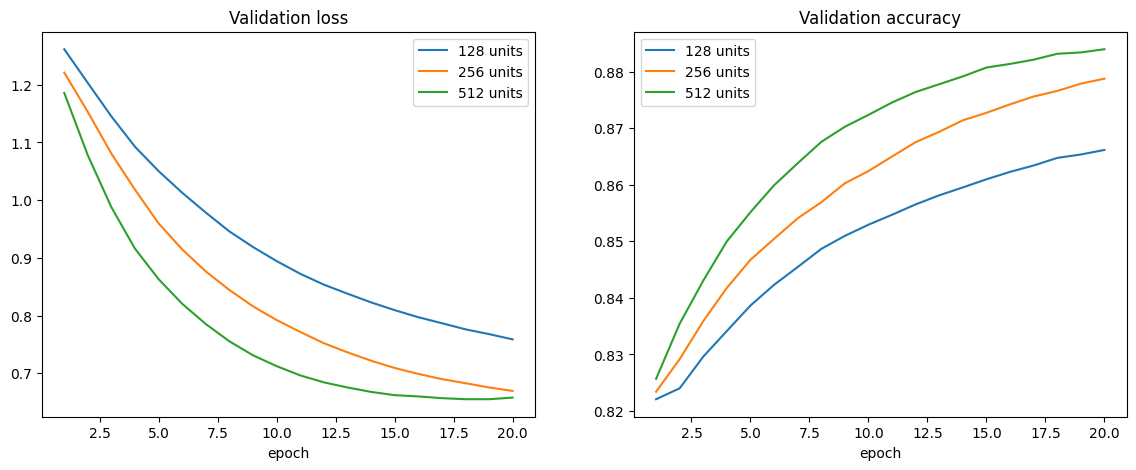

   units |  val_loss |  val_acc |    BLEU |       params
--------------------------------------------------------
     128 |    0.7587 |   0.8662 |  0.0439 |    3,196,832
     256 |    0.6694 |   0.8788 |  0.0708 |    6,373,280
     512 |    0.6550 |   0.8840 |  0.0608 |   13,905,824

Best configuration by BLEU: 256 units


In [32]:
# Validation loss and accuracy curves per configuration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for u in CONFIGS:
    h = results[u]['hist'].history
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['val_loss'], label=f'{u} units')
    axes[1].plot(ep, h['val_accuracy'], label=f'{u} units')
axes[0].set_title('Validation loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].set_title('Validation accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.show()

print(f"{'units':>8} | {'val_loss':>9} | {'val_acc':>8} | {'BLEU':>7} | {'params':>12}")
print("-" * 56)
for u in CONFIGS:
    r = results[u]
    print(f"{u:>8} | {r['val_loss']:>9.4f} | {r['val_acc']:>8.4f} | {r['bleu']:>7.4f} | {r['params']:>12,}")

best_units = max(CONFIGS, key=lambda u: results[u]['bleu'])
print("\nBest configuration by BLEU:", best_units, "units")

### 15. Ejemplos de traduccion del mejor modelo

Se presentan ejemplos tomados del dataset (con su traduccion de referencia) y
frases nuevas no vistas durante el entrenamiento.

In [33]:
enc_best = results[best_units]['enc_inf']
dec_best = results[best_units]['dec_inf']

print("--- Examples from the dataset ---")
np.random.seed(7)
for _ in range(5):
    i = np.random.randint(split_idx, len(input_sentences))
    pred = translate_seq(encoder_input_sequences[i:i+1], enc_best, dec_best)
    print(f"EN        : {input_sentences[i]}")
    print(f"ES (real) : {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred) : {pred}\n")

print("--- New sentences ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?",
          "The weather is nice today."]:
    print(f"EN : {s}")
    print(f"ES : {translate_text(s, enc_best, dec_best)}\n")

--- Examples from the dataset ---
EN        : Where is the book?
ES (real) : ¿Dónde está el libro?
ES (pred) : dónde está el libro

EN        : Is it OK if I go in jeans?
ES (real) : ¿Está bien si me voy de mezclilla?
ES (pred) : es lo que quiero ir a casa

EN        : Did you order the room to be swept?
ES (real) : ¿Ha ordenado que se limpie la habitación?
ES (pred) : te acordaste de vuelta a las luces de la estación

EN        : Tom didn't know where his family was.
ES (real) : Tom desconocía dónde se hallaba su familia.
ES (pred) : tom no sabe qué su padre

EN        : I have had a slight headache since last night.
ES (real) : Tengo un leve dolor de cabeza desde anoche.
ES (pred) : he estado casi casi todos los días

--- New sentences ---
EN : My mother says hi.
ES : mi madre le dijo a tom

EN : Where is the train station?
ES : dónde está el tren

EN : I love learning languages.
ES : me gusta estudiar inglés

EN : Can you help me?
ES : puedes ayudarme

EN : The weather is nice today

### 16. Actividad opcional: Beam search

Se implementa una decodificacion por busqueda en haz (*beam search*) con
puntuacion normalizada por longitud y se compara contra la decodificacion
*greedy* en las mismas frases.

In [34]:
def beam_search_translate(input_seq, enc_inf, dec_inf, beam_width=3):
    h, c = enc_inf.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    beams = [([sos], 0.0, h, c)]   # (tokens, log prob, state_h, state_c)
    completed = []

    for _ in range(max_out_len):
        new_beams = []
        for tokens, score, hh, cc in beams:
            if tokens[-1] == eos:
                completed.append((tokens, score))
                continue
            target = np.zeros((1, 1))
            target[0, 0] = tokens[-1]
            probs, nh, nc = dec_inf.predict([target, hh, cc], verbose=0)
            probs = probs[0, 0, :]
            for idx in np.argsort(probs)[-beam_width:]:
                new_beams.append((tokens + [int(idx)],
                                  score + float(np.log(probs[idx] + 1e-9)), nh, nc))
        if not new_beams:
            break
        new_beams.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
        beams = new_beams[:beam_width]
        if all(b[0][-1] == eos for b in beams):
            break

    candidates = completed + [(t, s) for t, s, _, _ in beams]
    candidates.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
    best = candidates[0][0]
    words = [idx2word_target.get(t, '') for t in best if t not in (sos, eos) and t > 0]
    return ' '.join(words)


print("--- Greedy vs beam search ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?",
          "The weather is nice today."]:
    seq = pad_sequences(input_tokenizer.texts_to_sequences([s]), maxlen=max_input_len)
    greedy = translate_seq(seq, enc_best, dec_best)
    beam = beam_search_translate(seq, enc_best, dec_best, beam_width=3)
    print(f"EN     : {s}")
    print(f"greedy : {greedy}")
    print(f"beam   : {beam}\n")

--- Greedy vs beam search ---
EN     : My mother says hi.
greedy : mi madre le dijo a tom
beam   : mi madre le dijo a tom

EN     : Where is the train station?
greedy : dónde está el tren
beam   : dónde está el tren

EN     : I love learning languages.
greedy : me gusta estudiar inglés
beam   : me gusta estudiar inglés

EN     : Can you help me?
greedy : puedes ayudarme
beam   : puedes ayudarme

EN     : The weather is nice today.
greedy : la primavera es la primavera
beam   : el día está ocupada



### 17. Actividad opcional: Muestreo aleatorio (sampling)

Ademas de greedy y beam search se agrega una decodificacion estocastica que
muestrea el siguiente token segun la distribucion de salida, controlada por una
temperatura. Una temperatura baja se acerca a greedy y una alta aumenta la
diversidad.

In [35]:
def sample_translate(input_seq, enc_inf, dec_inf, temperature=1.0):
    h, c = enc_inf.predict(input_seq, verbose=0)
    target = np.zeros((1, 1))
    target[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    out = []
    for _ in range(max_out_len):
        probs, h, c = dec_inf.predict([target, h, c], verbose=0)
        probs = probs[0, 0, :].astype('float64')
        # temperature scaling over the log probabilities
        probs = np.log(probs + 1e-9) / temperature
        probs = np.exp(probs)
        probs = probs / probs.sum()
        idx = int(np.random.choice(len(probs), p=probs))
        if idx == eos:
            break
        if idx > 0:
            out.append(idx2word_target.get(idx, ''))
        target[0, 0] = idx
    return ' '.join(out)


np.random.seed(13)
print("--- Greedy vs beam vs sampling ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?",
          "The weather is nice today."]:
    seq = pad_sequences(input_tokenizer.texts_to_sequences([s]), maxlen=max_input_len)
    print(f"EN              : {s}")
    print(f"greedy          : {translate_seq(seq, enc_best, dec_best)}")
    print(f"beam (w=3)      : {beam_search_translate(seq, enc_best, dec_best, beam_width=3)}")
    print(f"sampling (T=0.7): {sample_translate(seq, enc_best, dec_best, temperature=0.7)}")
    print(f"sampling (T=1.0): {sample_translate(seq, enc_best, dec_best, temperature=1.0)}\n")

--- Greedy vs beam vs sampling ---
EN              : My mother says hi.
greedy          : mi madre le dijo a tom
beam (w=3)      : mi madre le dijo a tom
sampling (T=0.7): mi madre quiere bonita
sampling (T=1.0): mi hermana trabaja en esposa

EN              : Where is the train station?
greedy          : dónde está el tren
beam (w=3)      : dónde está el tren
sampling (T=0.7): dónde el autobús se va a la
sampling (T=1.0): dónde estuviste el tren llegó

EN              : I love learning languages.
greedy          : me gusta estudiar inglés
beam (w=3)      : me gusta estudiar inglés
sampling (T=0.7): me encanta estudiar
sampling (T=1.0): conozco algunos francés

EN              : Can you help me?
greedy          : puedes ayudarme
beam (w=3)      : puedes ayudarme
sampling (T=0.7): puedes ayudarme
sampling (T=1.0): 

EN              : The weather is nice today.
greedy          : la primavera es la primavera
beam (w=3)      : el día está ocupada
sampling (T=0.7): hoy está muy bien hoy
sam

### 18. Actividad opcional: Embeddings preentrenados en espanol (decoder)

El encoder ya usa embeddings GloVe en ingles. Para completar la consigna de
embeddings preentrenados en ambos idiomas, se incorporan vectores fastText en
espanol de 300 dimensiones en el decoder, congelados durante el entrenamiento.
Se entrena un modelo de 256 unidades con esta variante y se compara contra el
modelo baseline de 256 unidades, que usa un embedding de decoder entrenable.

In [36]:
import gzip

# Pretrained Spanish word vectors from fastText (Common Crawl, 300 dimensions)
ES_VEC_GZ = 'cc.es.300.vec.gz'
ES_DIM = 300

if not os.path.exists(ES_VEC_GZ):
    print("Downloading Spanish fastText vectors...")
    os.system("curl -L -o cc.es.300.vec.gz "
              "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz")
    print("Download complete.")
else:
    print("Spanish vectors already available.")


def build_spanish_matrix(word2idx, nb_words, dim, gz_path):
    # Stream the file and keep only the vectors of words in our vocabulary
    matrix = np.zeros((nb_words, dim))
    wanted = {w: i for w, i in word2idx.items() if i < nb_words}
    found = 0
    with gzip.open(gz_path, 'rt', encoding='utf-8', errors='ignore') as f:
        next(f)  # skip the header line (word count and dimension)
        for line in f:
            parts = line.rstrip().split(' ')
            w = parts[0]
            if w in wanted:
                vec = np.asarray(parts[1:1 + dim], dtype='float32')
                if vec.shape[0] == dim:
                    matrix[wanted[w]] = vec
                    found += 1
                if found == len(wanted):
                    break
    return matrix, found


dec_embedding_matrix, es_found = build_spanish_matrix(
    word2idx_outputs, num_words_output, ES_DIM, ES_VEC_GZ)
print("Spanish vectors found:", es_found, "of", min(num_words_output, len(word2idx_outputs)))

Download complete.
Spanish vectors found: 9847 of 10000


In [37]:
es_units = 256
print("Training decoder with pretrained Spanish embeddings,", es_units, "units")
model_es, hist_es, layers_es = build_and_train(
    es_units, epochs=20, verbose=1,
    dec_emb_matrix=dec_embedding_matrix, dec_embed_dim=ES_DIM, tag="_es")

enc_es, dec_es = build_inference(layers_es, es_units)
bleu_es = evaluate_bleu(enc_es, dec_es, n_samples=150)
val_loss_es = float(np.min(hist_es.history['val_loss']))
val_acc_es = float(np.max(hist_es.history['val_accuracy']))
print(f"\nPretrained ES | val_loss={val_loss_es:.4f} | val_acc={val_acc_es:.4f} | BLEU={bleu_es:.4f}")

Training decoder with pretrained Spanish embeddings, 256 units
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.7869 - loss: 1.8608 - val_accuracy: 0.8103 - val_loss: 1.2691 - learning_rate: 5.0000e-04
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.8153 - loss: 1.2687 - val_accuracy: 0.8262 - val_loss: 1.1765 - learning_rate: 5.0000e-04
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.8249 - loss: 1.1805 - val_accuracy: 0.8322 - val_loss: 1.1064 - learning_rate: 5.0000e-04
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.8311 - loss: 1.1113 - val_accuracy: 0.8378 - val_loss: 1.0504 - learning_rate: 5.0000e-04
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.8353 - loss: 1.0545 - val_accuracy: 0.8417 - val_loss: 1.0036 - learning_rate: 5.0000e-04
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.8390 - loss: 1.0053 - val_accuracy: 0.8452 - val_loss: 0.9622 - learning_rate

In [38]:
# Compare the baseline 256 units model against the pretrained Spanish variant
b = results[256]
print("Decoder embedding comparison at 256 units")
print(f"{'variant':>16} | {'val_loss':>9} | {'val_acc':>8} | {'BLEU':>7}")
print("-" * 50)
print(f"{'trainable (base)':>16} | {b['val_loss']:>9.4f} | {b['val_acc']:>8.4f} | {b['bleu']:>7.4f}")
print(f"{'pretrained ES':>16} | {val_loss_es:>9.4f} | {val_acc_es:>8.4f} | {bleu_es:>7.4f}")

print("\n--- Translations with the pretrained Spanish decoder ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?",
          "The weather is nice today."]:
    print(f"EN : {s}")
    print(f"ES : {translate_text(s, enc_es, dec_es)}\n")

Decoder embedding comparison at 256 units
         variant |  val_loss |  val_acc |    BLEU
--------------------------------------------------
trainable (base) |    0.6694 |   0.8788 |  0.0708
   pretrained ES |    0.7135 |   0.8701 |  0.0418

--- Translations with the pretrained Spanish decoder ---
EN : My mother says hi.
ES : mi padre no le dijo a tom

EN : Where is the train station?
ES : dónde está el tren

EN : I love learning languages.
ES : me encanta francés

EN : Can you help me?
ES : puedes ayudarme

EN : The weather is nice today.
ES : el día está muy ocupado



### 19. Conclusiones

**Replicacion y extension**

Se replico la arquitectura *encoder decoder* con LSTM y embeddings GloVe del
notebook de clase y se la entreno sobre un corpus mas amplio: 30000 pares de los
118964 disponibles, frente a las 10000 del original. El vocabulario real fue de
8072 palabras en ingles y 13954 en espanol, acotado a 10000 por idioma. Las
longitudes de secuencia se subieron a 30 y 32 (en clase eran 20 y 22) para
cubrir las oraciones mas largas del corpus, cuyo maximo real es de 34 tokens en
ingles y 40 en espanol.

**Impacto del numero de neuronas en la capa recurrente**

| unidades | val_loss | val_acc | BLEU | parametros |
|:---:|:---:|:---:|:---:|:---:|
| 128 | 0.7587 | 0.8662 | 0.0439 | 3.196.832 |
| 256 | 0.6694 | 0.8788 | 0.0708 | 6.373.280 |
| 512 | 0.6550 | 0.8840 | 0.0608 | 13.905.824 |

La val_loss baja y el val_accuracy sube de forma monotona al aumentar las
neuronas (de 0.866 con 128 a 0.884 con 512). Sin embargo, el BLEU no es
monotono: alcanza su maximo con 256 unidades (0.0708) y cae con 512 (0.0608).
Esto deja una leccion clara: las metricas a nivel token pueden seguir mejorando
mientras la calidad real de la traduccion empeora. El modelo de 512 ajusta mejor
los tokens de entrenamiento pero generaliza peor al traducir, una senal de
sobreajuste. La mejor configuracion resulto ser la de 256 unidades, que logra el
BLEU mas alto con la mitad de los parametros del modelo de 512.

**Calidad de las traducciones**

El mejor modelo (256 unidades) traduce correctamente las frases cortas y
frecuentes:

* "Where is the book?" produce "donde esta el libro" (correcta).
* "Can you help me?" produce "puedes ayudarme" (correcta).
* "I love learning languages." produce "me gusta estudiar ingles" (fluida, con
  un desliz semantico: cambia idiomas por ingles).

En cambio, las frases largas o poco frecuentes se degradan:

* "Is it OK if I go in jeans?" produce "es lo que quiero ir a casa" (incoherente).
* "My mother says hi." produce "mi madre le dijo a tom" (pierde el sentido).
* "The weather is nice today." produce "la primavera es la primavera" (cae en una
  repeticion degenerada).

El val_accuracy a nivel token es alto (alrededor de 0.88) porque esta dominado
por el padding y las palabras frecuentes, por eso no refleja bien la calidad
real. El BLEU, mucho mas bajo (alrededor de 0.07), es una metrica mas
representativa y deja en claro que el traductor es util solo en oraciones
simples.

**Greedy, beam search y muestreo aleatorio**

En las frases cortas, las tres estrategias coinciden ("puedes ayudarme",
"donde esta el tren"). Las diferencias aparecen en los casos dificiles: para
"The weather is nice today." greedy cae en la repeticion "la primavera es la
primavera", mientras que beam search la evita y produce "el dia esta ocupada"
(igualmente incorrecta, pero sin el bucle). El muestreo aleatorio aporta
diversidad pero a costa de mas errores e incluso salidas vacias con temperatura
1.0. La conclusion es que, para un modelo de esta capacidad, greedy y beam son
mejores para la precision; beam ayuda sobre todo a evitar bucles de repeticion y
el sampling sirve para generar variedad, no para mejorar la calidad.

**Embeddings preentrenados en ambos idiomas**

El encoder usa GloVe en ingles en todas las configuraciones. Para el decoder se
probaron embeddings fastText en espanol de 300 dimensiones, congelados, con
9847 de 10000 palabras del vocabulario encontradas. El resultado, a 256
unidades, fue peor que el baseline en todas las metricas:

| variante (256) | val_loss | val_acc | BLEU |
|:---|:---:|:---:|:---:|
| embedding entrenable (base) | 0.6694 | 0.8788 | 0.0708 |
| fastText espanol congelado | 0.7135 | 0.8701 | 0.0418 |

El BLEU cae alrededor de un 40 por ciento (de 0.0708 a 0.0418). La interpretacion es que los
vectores genericos congelados no se adaptan a esta tarea ni a este corpus: un
embedding entrenado desde cero aprende representaciones mas utiles para el
objetivo concreto del decoder. Congelarlos impide esa adaptacion. Es probable
que con ajuste fino (descongelando los vectores) o con un corpus mas grande el
resultado mejorara. En sintesis, los embeddings preentrenados fueron utiles como
inicializacion del encoder en ingles, pero contraproducentes congelados en el
decoder en espanol.

**Limitaciones del enfoque**

* El modelo no tiene mecanismo de atencion, por lo que toda la oracion de
  entrada se comprime en un unico vector de estado; este cuello de botella
  explica la degradacion y los bucles de repeticion en oraciones largas.
* El vocabulario esta acotado a 10000 palabras, mientras que el espanol real del
  corpus tiene 13954, de modo que los terminos poco frecuentes quedan fuera.
* El BLEU se calcula contra una unica referencia, por lo que penaliza
  traducciones validas que no coinciden con ella y subestima la calidad.
* El corpus, aunque triplica al de clase, sigue siendo chico para una tarea de
  traduccion general.

**Sintesis**

Aumentar el numero de neuronas mejora las metricas a nivel token, pero con
rendimientos decrecientes y hasta negativos en BLEU a partir de las 256
unidades, que fue la mejor configuracion. Los embeddings preentrenados
congelados en el decoder no ayudaron, beam search evita los bucles de repeticion
y el muestreo aleatorio aporta diversidad. La calidad alcanzada es razonable
para frases simples pero insuficiente para traduccion general, y el principal
camino de mejora seria incorporar un mecanismo de atencion.